# Empirical determination of the Kraft break in the stellar-obliquity sample

This notebook empirically locates the **Kraft break** — the host effective
temperature at which the distribution of sky-projected stellar obliquities $\lambda$
changes most sharply between the cool and hot subsamples — using a
**bootstrap + Monte Carlo + sliding KS-test** procedure.

**Inputs**:
- `obliquity_singles.csv` — hot-Jupiter hosts with no detected stellar companion
- `obliquity_binaries.csv` — hot-Jupiter hosts with detected stellar companion

**Algorithm**
1. Bootstrap-resample the single-star sample (with replacement)
2. Perturb each $(T_{\rm eff},\,\lambda)$ value by a Gaussian draw using its 1$\sigma$ uncertainty
3. Scan every possible temperature cut: for each candidate, compute the two-sample
   Kolmogorov-Smirnov $p$-value between the $\lambda$ distributions on either side
4. Record the cut that maximises the KS significance $-\log_{10}(p)$
5. Repeat $N=10\,0000$ times and take the median $\pm 1\sigma$ of the maximum-significance cut

The result is a **data-driven** Kraft-break temperature with a Monte Carlo uncertainty.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
import warnings
from matplotlib.ticker import AutoMinorLocator

warnings.filterwarnings('ignore')

# plt.rcParams.update({
#     'font.family': 'Times New Roman',
#     'mathtext.fontset': 'custom',
#     'mathtext.rm': 'Times New Roman',
#     'mathtext.it': 'Times New Roman:italic',
# })

def ticksetax(ax, labelsize=13, spine_width=1.5):
    ax.tick_params(direction='in', which='both', width=spine_width,
                   bottom=True, top=True, left=True, right=True, labelsize=labelsize)
    for s in ax.spines.values():
        s.set_linewidth(spine_width)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

rng = np.random.default_rng(seed=0)   # reproducible

In [ ]:
%%file obliquity_singles.csv
System,teff,teffuerr,tefflerr,Pflag,lambdadeg,lambdadeguerr,lambdadeglerr,psi,psiuerr,psilerr,Author_string,Ephemeris_Url,normalized_lambdadeg,normalized_lambdauerr,normalized_lambdalerr,Albrecht2022_Excluded_Flag,BinaryMultiStarFlag,TIC,SOCatflag,Method,pl_orbper,pl_orbperuerr,pl_orbperlerr,pl_orbeccen,pl_orbeccenuerr,pl_orbeccenlerr,pl_orbsmax,pl_orbsmaxuerr,pl_orbsmaxlerr,pl_orbincl,pl_orbincluerr,pl_orbincllerr,pl_bmassj,pl_bmassjuerr,pl_bmassjlerr,pl_radj,pl_radjuerr,pl_radjlerr,pl_ratror,pl_ratroruerr,pl_ratrorlerr,pl_ratdor,pl_ratdoruerr,pl_ratdorlerr,pl_imppar,pl_impparuerr,pl_impparlerr,pl_trandur,pl_tranduruerr,pl_trandurlerr,st_mass,st_massuerr,st_masslerr,st_vsin,st_vsinuerr,st_vsinlerr,st_rad,st_raduerr,st_radlerr,st_met,st_metuerr,st_metlerr,st_logg,st_logguerr,st_logglerr,st_age,st_ageuerr,st_agelerr,Gaia DR3,Gaia Teff,Ruwe,q
HAT-P-06,6570,80,80,y,165.0,6.0,6.0,-999.0,-999.0,-999.0,Albrecht_et_al._(2012),https://ui.adsabs.harvard.edu/abs/2012ApJ...757...18A,165.0,6.0,6.0,0,,TIC 176899385,y,RM,3.85298,5e-06,5e-06,0.0,,,0.05239,0.0008,0.00082,85.51,0.35,0.35,1.32,0.3,0.3,1.48,0.15,0.15,0.0934,0.0005,0.0005,7.73,0.34,0.34,0.602,0.03,0.03,3.5064,0.0408,0.0408,1.79,0.6,0.6,7.8,0.6,0.6,1.62,0.17,0.17,-0.13,,,4.22,0.03,0.03,2.3,0.5,0.7,Gaia DR3 1925321658551399040,6715.8354,1.2652596,0.0007039465859438597
HAT-P-09,6350,150,150,y,-16.0,8.0,8.0,-999.0,-999.0,-999.0,Moutou_et_al._(2011),https://ui.adsabs.harvard.edu/abs/2011A%26A...533A.113M,16.0,8.0,8.0,0,,TIC 371234684,y,RM,3.92281072,1.02e-06,1.02e-06,0.084,0.052,0.047,0.05287,0.00078,0.00078,86.44,0.37,0.36,0.749,0.064,0.063,1.393,0.067,0.065,0.10696,0.00086,0.00087,8.5,0.34,0.35,0.51,0.044,0.052,3.36,0.0336,0.0336,1.281,0.057,0.056,11.9,1.0,1.0,1.338,0.065,0.06,0.12,0.2,0.2,4.293,0.033,0.035,1.6,1.8,1.4,Gaia DR3 898130030131443584,6146.142,1.072309,0.0005581507269656708
HAT-P-13,5653,90,90,y,1.9,8.6,8.6,-999.0,-999.0,-999.0,Winn_et_al._(2010),https://ui.adsabs.harvard.edu/abs/2010ApJ...718..575W,1.9,8.6,8.6,0,,TIC 20096620,y,RM,2.91625,1.5e-05,1.5e-05,0.0133,0.0041,0.0041,0.04383,0.00068,0.00068,83.4,0.68,0.68,0.851,0.038,0.038,1.272,0.065,0.065,0.08389,0.00081,0.00081,5.8928,0.2611,0.2398,0.679,0.043,0.043,3.28681,0.0285336,0.0285336,1.32,0.062,0.062,1.66,0.37,0.37,1.756,0.046,0.046,0.46,0.07,0.07,4.13,0.04,0.04,5.0,2.5,0.7,Gaia DR3 1014520826353577088,5758.428,1.1245627,0.0006154240099302238
HAT-P-23,5885,72,72,y,15.0,22.0,22.0,-999.0,-999.0,-999.0,Moutou_et_al._(2011),https://ui.adsabs.harvard.edu/abs/2011A%26A...533A.113M,15.0,22.0,22.0,0,,TIC 305243225,y,RM,1.212884,2e-06,2e-06,0.106,0.044,0.044,0.0232,0.0002,0.0002,85.1,1.5,1.5,2.09,0.111,0.111,1.368,0.09,0.09,0.1169,0.0012,0.0012,4.14,0.23,0.23,0.324,0.07,0.101,2.1792,0.0168,0.0168,1.13,0.035,0.035,8.1,0.5,0.5,1.203,0.074,0.074,0.15,0.04,0.04,4.33,0.05,0.05,4.0,1.0,1.0,Gaia DR3 1808938730710633984,5774.3516,0.8600453,0.0017655769460140612
HAT-P-36,5620,40,40,y,-14.0,18.0,18.0,0.0,63.0,0.0,Mancini_et_al._(2015),https://ui.adsabs.harvard.edu/abs/2015A%26A...579A.136M,14.0,18.0,18.0,0,,TIC 373693175,y,RM,1.32734683,4.8e-07,4.8e-07,0.063,0.021,0.023,0.0241,0.00047,0.00047,87.13,0.004,0.13,1.8482,0.087,0.087,1.277,0.02,0.02,0.1199,0.0002,0.0002,4.95,0.042,0.042,0.25,0.007,0.007,2.232,0.0384,0.00168,1.03,0.03,0.03,3.58,0.5,0.5,1.041,0.013,0.013,0.25,0.09,0.09,4.416,0.011,0.011,6.6,2.9,1.8,Gaia DR3 1541532207133249920,5723.511,0.938986,0.0017128942361379674
HAT-P-49,6820,52,52,y,-97.7,1.8,1.8,-999.0,-999.0,-999.0,Bourrier_et_al._(2023),https://ui.adsabs.harvard.edu/abs/2023A%26A...669A..63B,97.7,1.8,1.8,0,,TIC 99224131,y,RMR,2.69155,6e-06,6e-06,0.0,,,0.04378,0.00048,0.00049,86.2,1.7,1.7,2.2,0.59,0.59,1.59,0.18,0.18,0.0792,0.0019,0.0019,5.15,0.31,0.31,0.34,0.119,0.141,4.1088,0.0456,0.0456,2.22,0.83,0.83,10.68,0.46,0.47,2.06,0.23,0.23,0.07,,,4.1,0.04,0.04,1.5,0.2,0.2,Gaia DR3 1835842749465226368,6739.136,0.96423,0.0009459942859155472
HATS-02,5227,95,95,y,3.0,18.0,18.0,38.0,27.0,27.0,Biagiotti_et_al._(2024),https://ui.adsabs.harvard.edu/abs/2024A%26A...685A.131B,3.0,18.0,18.0,0,,TIC 413376180,y,RM,1.35413379,8e-08,8e-08,0.0,,,0.02317,0.00044,0.00044,87.83,0.18,0.18,1.37,0.16,0.16,1.122,0.024,0.024,0.1335,0.001,0.001,5.5,0.09,0.09,0.271,0.055,0.074,2.0688,0.0096,0.0096,0.904,0.052,0.052,1.5,0.5,0.5,0.876,0.02,0.02,0.15,0.05,0.05,4.51,0.012,0.012,7.2,4.7,8.1,Gaia DR3 3492502001623237888,5039.543,1.0589337,0.0014466748899756362
HATS-03,6351,76,76,y,3.0,25.0,25.0,-999.0,-999.0,-999.0,Addison_et_al._(2014),https://ui.adsabs.harvard.edu/abs/2014ApJ...792..112A,3.0,25.0,25.0,0,,TIC 336732616,y,RM,3.547851,5e-06,5e-06,0.0,,,0.0485,0.0004,0.0006,86.2,0.3,0.3,1.071,0.136,0.136,1.381,0.035,0.035,0.1011,0.0006,0.0006,7.42,0.12,0.12,0.497,0.024,0.027,3.5856,0.0168,0.0168,1.209,0.036,0.036,9.12,1.31,1.31,1.404,0.03,0.03,-0.157,0.07,0.07,4.22,0.01,0.01,3.2,0.6,0.4,Gaia DR3 6805886373600546176,6109.0044,1.0518343,0.0008456331055261762
HD_118203,5788,51,51,n,-12.0,8.0,10.0,0.0,33.5,0.0,Zhang_et_al._(2024),https://ui.adsabs.harvard.edu/abs/arXiv:2407.21377,12.0,10.0,8.0,0,,TIC 286923464,y,RM,6.1349779,2e-06,2e-06,0.3136,0.0075,0.0075,0.0713,0.002,0.002,88.48,0.73,0.93,2.14,0.12,0.12,1.14,0.029,0.029,0.05573,0.00025,0.00021,7.46,0.11,0.14,0.155,0.09,0.074,5.643,0.016,0.014,1.27,0.028,0.032,5.89,0.31,0.26,2.04,0.03,0.03,0.287,0.069,0.111,3.92,0.02,0.02,4.73,0.39,0.39,Gaia DR3 1560420854826284928,5943.831,0.96064395,0.001608528866688469
HD_209458,6117,50,50,y,1.58,0.08,0.08,-999.0,-999.0,-999.0,Casasayas-Barris_et_al._(2021),https://ui.adsabs.harvard.edu/abs/2021A%26A...647A..26C,1.58,0.08,0.08,0,,TIC 420814525,y,RM,3.52474859,3.8e-07,3.8e-07,0.0,,,0.04707,0.00045,0.00047,86.71,0.05,0.05,0.73,0.04,0.04,1.39,0.02,0.02,0.12086,0.0001,0.0001,8.81,0.19,0.19,0.507,0.005,0.005,3.072,0.003,0.003,1.23,0.09,0.09,4.4,0.2,0.2,1.19,0.02,0.02,0.01,,,4.45,0.02,0.02,3.1,0.8,0.7,Gaia DR3 1779546757669063552,5996.3154,0.9842082,0.0005665477973964287
K2-034,6131,47,47,y,-1.0,10.0,9.0,-999.0,-999.0,-999.0,Hirano_et_al._(2016),https://ui.adsabs.harvard.edu/abs/2016ApJ...825...53H,1.0,9.0,10.0,0,,TIC 178217113,y,RM,2.9956348,2e-07,2e-07,0.0,,,0.0442,0.002,0.002,82.23,0.19,0.19,1.698,0.061,0.05,1.22669495,0.05174422,0.05263637,0.0887,0.0005,0.0005,6.68,0.1,0.1,0.83,0.01,0.01,2.4768,0.00912,0.00888,1.16,0.04,0.04,6.31,0.2,0.2,1.42,0.06,0.05,0.01,0.03,0.04,4.2,0.03,0.03,2.88,0.26,0.24,Gaia DR3 665757593450097920,5984.184,1.1001163,0.0013973284562757878
KELT-07,6699,24,24,y,-10.55,0.27,0.27,12.4,11.7,11.7,Tabernero_et_al._(2022),https://ui.adsabs.harvard.edu/abs/2022MNRAS.515.1247T,10.55,0.27,0.27,0,,TIC 367366318,y,RM,2.73477,4e-06,4e-06,0.0,,,0.04415,0.00062,0.00052,83.76,0.38,0.38,1.39,0.22,0.22,1.6,0.06,0.06,0.0922,0.0004,0.0004,5.5,0.17,0.17,0.593,0.017,0.017,3.5112,0.02328,0.02208,1.76,0.25,0.25,69.3,0.2,0.2,1.81,0.07,0.07,0.0,,,4.5,,,1.3,0.2,0.2,Gaia DR3 181908842994567936,6580.7725,0.9919734,0.0007539124916007736
KELT-10,5948,74,74,y,-5.2,3.4,3.4,-999.0,-999.0,-999.0,Steiner_et_al._(2023),https://ui.adsabs.harvard.edu/abs/2023A%26A...672A.134S,5.2,3.4,3.4,0,,TIC 269217040,y,RMR,4.1662739,6.3e-06,6.3e-06,,,,0.0525,0.00086,0.00097,88.61,0.86,0.74,0.679,0.039,0.038,1.399,0.069,0.049,0.119,0.0014,0.0012,9.34,0.21,0.32,0.23,0.11,0.14,3.744,0.0384,0.0288,1.112,0.055,0.061,2.58,0.12,0.12,1.209,0.047,0.035,0.09,0.11,0.1,4.319,0.02,0.03,4.5,0.7,0.7,Gaia DR3 6710517793025165696,5711.9224,0.8989,0.0005828862273967371
KELT-17,7454,49,49,y,-115.9,4.1,4.1,116.0,4.0,4.0,Zhou_et_al._(2016),https://ui.adsabs.harvard.edu/abs/2016AJ....152..136Z,115.9,4.1,4.1,0,,TIC 6893917,y,RM&DT,3.0801716,5.3e-06,5.2e-06,,,,0.04881,0.00065,0.00061,84.87,0.45,0.43,1.31,0.28,0.29,1.525,0.065,0.06,0.09526,0.00088,0.00085,6.38,0.18,0.18,0.57,0.031,0.035,3.4752,0.0336,0.0312,1.635,0.066,0.061,44.2,1.5,1.3,1.645,0.06,0.055,-0.018,0.074,0.072,4.22,0.022,0.024,0.65,0.15,0.15,Gaia DR3 651935220461650560,7346.182,0.94404626,0.0007648430865442298
Kepler-008,6213,150,150,y,5.0,7.0,7.0,-999.0,-999.0,-999.0,Albrecht_et_al._(2012),https://ui.adsabs.harvard.edu/abs/2012ApJ...757...18A,5.0,7.0,7.0,0,,TIC 123233041,y,RM,3.5224991,7e-07,7e-07,0.0,,,0.0474,0.0018,0.0021,83.978,0.036,0.033,0.59,0.13,0.12,1.416,0.053,0.062,0.095751,0.00019,0.00023,6.854,0.018,0.017,0.7191,0.0021,0.0023,3.19061,0.00633,0.00633,1.213,0.067,0.062,10.5,0.7,0.7,1.486,0.053,0.062,-0.055,0.03,0.03,4.174,0.026,0.026,3.47,0.6,0.5,Gaia DR3 2116730994965905280,6128.689,0.9569958,0.0004643121170996716
NGTS-02,6450,50,50,y,-11.3,4.8,4.8,-999.0,-999.0,-999.0,Anderson_et_al._(2018),https://ui.adsabs.harvard.edu/abs/arXiv:1809.07709,11.3,4.8,4.8,0,,TIC 125739286,y,RM&DT,4.511164,6.1e-05,6.1e-05,0.0,,,0.063,0.0024,0.003,88.5,1.0,1.2,0.74,0.13,0.12,1.595,0.047,0.045,0.09619,0.00114,0.00088,8.0,0.4,0.4,,,,4.651,0.046,0.038,1.64,0.19,0.22,15.2,0.8,0.8,1.702,0.047,0.044,-0.06,0.09,0.09,4.197,0.03,0.059,2.17,0.37,0.37,Gaia DR3 6220602384081327104,6586.501,1.0709726,0.0004307315445959149
Qatar-7,6387,38,38,y,-9.0,11.0,11.0,-999.0,-999.0,-999.0,Zak_et_al._(2025),https://ui.adsabs.harvard.edu/abs/arXiv:2505.20516,9.0,11.0,11.0,0,,TIC 291685334,y,RM,2.032046,9.7e-06,1.4e-05,0.0,,,0.0352,0.0002,0.0002,89.0,1.0,1.0,1.88,0.25,0.25,1.7,0.03,0.03,0.11,0.001,0.001,4.84,0.05,0.05,0.08,0.08,0.08,3.5784,0.0216,0.0216,1.409,0.026,0.026,13.8,0.5,0.5,1.564,0.021,0.021,0.276,0.071,0.071,4.196,0.029,0.029,1.69,0.25,0.25,Gaia DR3 2878923523472328704,6390.0615,0.9281515,0.0012736956422017961
TOI-1181,5990,95,95,y,-2.0,16.0,15.0,-999.0,-999.0,-999.0,Saunders_et_al.(2024),https://ui.adsabs.harvard.edu/abs/2024AJ....168...81S,2.0,15.0,16.0,0,,TIC 229510866,y,RM,2.103189,3e-06,5e-06,0.011,0.007,0.008,0.0364,0.0006,0.007,87.0,1.3,1.3,1.179,0.023,0.023,1.519,0.059,0.059,0.07947,0.00042,0.00045,3.976,0.078,0.049,0.329214,0.02657,0.029747,4.1218716,0.0059798,0.0060347,1.467,0.024,0.024,10.6,1.0,1.0,1.961,0.03,0.03,0.38,0.06,0.06,4.02,0.02,0.02,2.7,0.2,0.2,Gaia DR3 2241587416547315584,5905.15,0.87917113,0.000767189230981482
TOI-1431,7690,400,250,y,-155.0,20.0,10.0,-999.0,-999.0,-999.0,Stangret_et_al._(2021),https://ui.adsabs.harvard.edu/abs/2021A%26A...654A..73S,155.0,10.0,20.0,0,,TIC 375506058,y,RM,2.650237,3e-06,3e-06,0.0022,0.003,0.0016,0.046,0.002,0.002,80.13,0.13,0.13,3.12,0.18,0.18,1.49,0.05,0.05,0.07955,0.00063,0.00053,5.15,0.05,0.05,0.881,0.004,0.004,2.489,0.009,0.009,1.9,0.1,0.08,6.0,0.2,0.2,1.92,0.07,0.07,0.09,0.03,0.03,4.15,0.04,0.04,0.29,0.32,0.19,Gaia DR3 2188906825165621120,7426.445,0.90158707,0.0015675442157812075
TOI-2046,6250,140,140,y,-1.0,6.0,6.0,42.0,10.0,8.0,Zak_et_al._(2025),https://ui.adsabs.harvard.edu/abs/2025A%26A...694A..91Z,1.0,6.0,6.0,0,,TIC 468574941,y,RM,1.4971842,3.1e-06,3.3e-06,,,,,,,83.6,0.9,0.9,2.3,0.28,0.28,1.44,0.11,0.11,0.1213,0.0017,0.0021,4.75,0.18,0.17,0.51,0.06,0.07,2.41,0.032,0.03,1.13,0.19,0.19,9.8,1.6,1.6,1.21,0.07,0.07,-0.06,0.15,0.15,4.3,0.15,0.15,0.45,0.43,0.021,Gaia DR3 538759464958942208,5910.6733,0.8721999,0.0019429794142738473
TOI-4379,6020,100,100,y,-1.0,22.0,29.0,-999.0,-999.0,-999.0,Saunders_et_al.(2024),https://ui.adsabs.harvard.edu/abs/2024AJ....168...81S,1.0,29.0,22.0,0,,TIC 97766057,y,RM,3.25352,2e-05,2e-05,0.018,0.029,0.018,,,,,,,1.113,0.071,0.071,1.489,0.079,0.079,0.077,0.002,0.002,4.63,0.56,0.21,,,,5.1881112,0.1222413,0.1222413,1.372,0.037,0.105,5.9,1.0,1.0,1.976,0.04,0.04,0.16,0.06,0.06,3.929,0.038,0.023,4.51,0.4,1.21,Gaia DR3 6027376203516634112,6174.1772,0.8959662,0.0007743902204138911
TOI-640,6460,130,150,y,184.0,3.0,3.0,104.0,2.0,2.0,Knudstrup_et_al._(2023),https://ui.adsabs.harvard.edu/abs/2023A%26A...671A.164K,176.0,3.0,3.0,0,,TIC 147977348,y,RM,5.003777,2e-06,3e-06,0.013,,,0.06608,0.00098,0.0011,81.79,0.16,0.12,0.57,0.02,0.02,1.72,0.05,0.05,0.0851,0.0003,0.0004,6.33,0.07,0.06,0.904,0.005,0.007,3.696,0.018,0.019,1.536,0.069,0.076,5.9,0.4,0.4,2.082,0.064,0.058,0.072,0.085,0.076,3.987,0.03,0.036,1.99,0.55,0.4,Gaia DR3 5580554052549277056,6137.0757,1.1238917,0.0003542439540120541
TOI-778,6643,150,150,y,18.0,11.0,11.0,-999.0,-999.0,-999.0,Clark_et_al._(2023),https://ui.adsabs.harvard.edu/abs/2023AJ....165..207C,18.0,11.0,11.0,0,,TIC 335630746,y,RM,4.633611,1e-06,1e-06,0.21,0.04,0.04,0.06,0.003,0.003,84.7,0.3,0.4,2.8,0.2,0.2,1.37,0.04,0.04,0.0825,0.0005,0.0005,7.6,0.2,0.2,0.61,0.02,0.02,3.76,0.01,0.01,1.4,0.05,0.05,39.9,4.5,4.3,1.71,0.05,0.05,0.0,0.1,0.1,4.05,0.17,0.17,1.95,0.14,0.13,Gaia DR3 3607877948613218304,6649.0503,1.0880959,0.0019091884679386499
WASP-004,5540,55,55,y,4.0,34.0,43.0,-999.0,-999.0,-999.0,Triaud_et_al._(2010),https://ui.adsabs.harvard.edu/abs/2010A%26A...524A..25T,4.0,34.0,43.0,0,,TIC 402026209,y,RM,1.338230994,8.4e-08,8.4e-08,0.0053,0.0038,0.0038,0.02261,0.00036,0.00027,88.05,0.85,0.53,1.2,0.032,0.03,1.349,0.011,0.012,0.15205,0.0006,0.00062,5.411,0.053,0.05,0.184,0.048,0.079,2.16648,0.00576,0.00576,0.899,0.033,0.031,1.97,0.26,0.26,0.912,0.007,0.007,-0.05,0.04,0.04,4.472,0.013,0.012,7.0,2.9,2.9,Gaia DR3 6535499658122055552,5502.5938,1.0529404,0.0012742080987354727
WASP-005,5770,65,65,n,7.2,9.5,9.5,-999.0,-999.0,-999.0,Fukui_et_al._(2011),https://ui.adsabs.harvard.edu/abs/2011PASJ...63..287F,7.2,9.5,9.5,0,,TIC 184240683,y,RM,1.6284279,2.2e-06,4.9e-06,0.038,0.026,0.018,0.0267,0.0012,0.0008,86.9,2.8,0.7,1.58,0.13,0.1,1.087,0.068,0.071,0.1108,0.0011,0.0011,5.4,0.15,0.13,0.31,0.06,0.28,2.3688,0.0528,0.048,0.96,0.13,0.09,3.5,1.0,1.0,1.029,0.056,0.069,0.09,0.09,0.09,4.395,0.043,0.04,5.4,4.4,4.3,Gaia DR3 6533307957785865856,5615.818,1.0682267,0.001571103010074514
WASP-007,6520,70,70,y,86.0,6.0,6.0,-999.0,-999.0,-999.0,Albrecht_et_al._(2012),https://ui.adsabs.harvard.edu/abs/2012ApJ...744..189A,86.0,6.0,6.0,0,,TIC 389352124,y,RM,4.9546416,3.5e-06,3.5e-06,0.034,0.045,0.024,0.0617,0.0011,0.0011,87.03,0.93,0.93,0.96,0.13,0.13,1.33,0.093,0.093,0.0956,0.0016,0.0016,9.074,0.532,0.476,0.53,0.038,0.05,3.639,0.027,0.027,1.276,0.065,0.065,17.0,2.0,2.0,1.432,0.092,0.092,0.0,0.1,0.1,4.232,0.047,0.047,2.4,0.9,1.1,Gaia DR3 6681720724498802176,6402.9277,0.8894097,0.0007181900192872664
WASP-013,6025,21,21,y,8.0,13.0,12.0,-999.0,-999.0,-999.0,Brothwell_et_al._(2014),https://ui.adsabs.harvard.edu/abs/2014MNRAS.440.3392B,8.0,13.0,12.0,0,,TIC 8767448,y,RM,4.35301,3e-06,3e-06,0.0,,,0.05362,0.00074,0.00085,85.43,0.29,0.29,0.36,0.09,0.09,1.22,0.14,0.14,0.0932,0.001,0.0011,7.35,0.26,0.26,0.574,0.033,0.042,4.003,0.024,0.024,0.72,0.25,0.25,5.7,0.4,0.4,1.37,0.15,0.15,0.0,,,4.06,0.1,0.1,5.0,2.6,1.7,Gaia DR3 702295464353437952,6052.2764,0.885122,0.00047729711698466247
WASP-015,6573,70,70,y,-139.6,4.3,5.2,-999.0,-999.0,-999.0,Triaud_et_al._(2010),https://ui.adsabs.harvard.edu/abs/2010A%26A...524A..25T,139.6,5.2,4.3,0,,TIC 111991770,y,RM,3.7521,1e-05,1e-05,0.0,,,0.05165,0.00067,0.00067,85.96,0.35,0.35,0.54,0.29,0.29,1.41,0.36,0.36,0.09842,0.00067,0.00058,7.29,0.38,0.38,0.525,0.037,0.028,3.7128,0.0288,0.0216,1.18,0.93,0.93,4.27,0.26,0.36,1.48,0.38,0.38,-0.17,,,4.35,0.15,0.15,2.4,0.6,0.7,Gaia DR3 6171009049549197824,6371.4927,1.2096531,0.0004368482087656233
WASP-016,5630,70,70,y,-4.2,11.0,13.9,-999.0,-999.0,-999.0,Brown_et_al._(2012),https://ui.adsabs.harvard.edu/abs/2012MNRAS.423.1503B,4.2,13.9,11.0,0,,TIC 46096489,y,RM,3.1186,1.4e-05,1.4e-05,0.0,,,0.0415,0.00077,0.00077,85.22,0.35,0.35,1.24,0.25,0.25,1.22,0.1,0.1,0.1079,0.0012,0.0012,9.52,0.57,0.57,0.81,0.023,0.026,2.043274,0.024721,0.024721,1.78,0.54,0.54,3.2,0.9,0.9,1.14,0.09,0.09,0.01,,,4.49,0.04,0.04,8.6,3.4,2.8,Gaia DR3 6283723285046532864,5475.332,1.0978453,0.0006649982304055971
WASP-017,6550,100,100,n,-148.7,7.7,6.7,-999.0,-999.0,-999.0,Anderson_et_al._(2011),https://ui.adsabs.harvard.edu/abs/2011MNRAS.416.2108A,148.7,6.7,7.7,0,,TIC 66818296,y,RM,3.73543,8e-06,8e-06,0.0,,,0.0515,0.00034,0.00034,86.63,0.42,0.42,0.78,0.23,0.23,1.87,0.24,0.24,0.12472,0.00016,0.00016,8.97,0.62,0.62,0.4,0.043,0.04,4.4232,0.0312,0.024,2.28,0.99,0.99,9.92,0.4,0.45,1.49,0.19,0.19,-0.25,,,4.2,0.2,0.2,2.65,0.25,0.25,Gaia DR3 6042793005779654656,6617.9907,1.0731817,0.0003265717116210849
WASP-019,5460,90,90,y,-1.9,1.1,1.1,-999.0,-999.0,-999.0,Sedaghati_et_al._(2021),https://ui.adsabs.harvard.edu/abs/2021MNRAS.505..435S,1.9,1.1,1.1,0,,TIC 35516889,y,RM,0.78883852,7.5e-07,8.2e-07,0.0126,0.014,0.0089,0.01652,0.0005,0.00056,79.08,0.34,0.37,1.154,0.078,0.08,1.415,0.044,0.048,0.1441,0.00049,0.0005,3.533,0.048,0.052,0.6671,0.0087,0.0091,1.607,0.007,0.007,0.965,0.091,0.095,4.63,0.26,0.26,1.006,0.031,0.034,0.04,0.25,0.3,4.417,0.02,0.021,6.4,4.1,3.5,Gaia DR3 5411736896952029568,5454.128,0.8484438,0.0011415562134721253
WASP-028,6084,45,45,n,6.0,17.0,17.0,-999.0,-999.0,-999.0,Mocnik_et_al._(2020),https://ui.adsabs.harvard.edu/abs/2020PASP..132a4401M,6.0,17.0,17.0,0,,TIC 398572544,y,RM,3.40883495,1.5e-07,1.5e-07,0.0,,,0.0442,0.001,0.001,88.514,0.09,0.09,0.889,0.058,0.058,1.219,0.028,0.028,0.116,0.0017,0.0014,8.62,0.1,0.1,0.228,0.013,0.013,3.2388,0.002,0.002,0.993,0.067,0.067,3.25,0.34,0.34,1.083,0.025,0.025,-0.2,0.07,0.07,4.37,0.018,0.018,5.5,2.6,2.6,Gaia DR3 2641087471777046016,6004.221,0.9903205,0.0008546165901296373
WASP-031,6175,70,70,y,2.8,3.1,3.1,-999.0,-999.0,-999.0,Brown_et_al._(2012),https://ui.adsabs.harvard.edu/abs/2012MNRAS.423.1503B,2.8,3.1,3.1,0,,TIC 437248515,y,RM,3.4059096,5e-06,5e-06,0.0,,,0.04659,0.00035,0.00035,84.41,0.22,0.22,0.478,0.029,0.029,1.549,0.05,0.05,0.1271,0.0011,0.0011,8.0,0.19,0.19,0.77,0.01,0.02,2.6472,0.0312,0.0312,1.163,0.026,0.026,7.9,0.6,,1.252,0.033,0.033,-0.2,0.09,0.09,4.308,0.02,0.02,1.0,3.0,0.5,Gaia DR3 3545873945303316224,6173.6855,0.99333346,0.00039234397578446887
WASP-035,6072,62,62,y,-5.0,11.0,11.0,-999.0,-999.0,-999.0,Zak_et_al._(2025),https://ui.adsabs.harvard.edu/abs/arXiv:2505.20516,5.0,11.0,11.0,0,,TIC 43647325,y,RM,3.16158,2e-06,2e-06,0.0,,,0.04317,0.00033,0.00033,87.96,0.28,0.28,0.71,0.1,0.1,1.3,0.07,0.07,0.1241,0.0008,0.0008,8.53,0.21,0.21,0.257,0.065,0.093,3.1425792,0.011049,0.011049,1.05,0.19,0.19,3.9,0.4,0.4,1.08,0.06,0.06,-0.15,,,4.4,0.01,0.01,5.0,1.2,1.2,Gaia DR3 3211188618762023424,5875.2974,0.9675914,0.0006454875296364006
WASP-041,5546,33,33,n,29.0,10.0,14.0,-999.0,-999.0,-999.0,Neveu-VanMalle_et_al._(2016),https://ui.adsabs.harvard.edu/abs/2016A%26A...586A..93N,29.0,10.0,14.0,0,,TIC 398943781,y,RM,3.0524,1e-06,1e-06,0.0,,,0.04022,0.00044,0.00044,89.4,0.3,0.3,0.85,0.11,0.11,1.1,0.05,0.05,0.1365,0.0006,0.0006,9.96,0.42,0.42,0.1,0.06,0.06,2.6376,0.0048,0.0048,0.81,0.15,0.15,2.64,0.25,0.25,0.83,0.04,0.04,0.06,,,4.53,0.05,0.05,1.2,1.1,0.2,Gaia DR3 6160877943251930368,5425.766,1.056303,0.00100173468996781
WASP-044,5400,150,150,y,-18.0,20.0,26.0,-999.0,-999.0,-999.0,Zak_et_al._(2025),https://ui.adsabs.harvard.edu/abs/arXiv:2505.20516,18.0,26.0,20.0,0,,TIC 12862099,y,RM,2.423804,8e-06,8e-06,0.0,,,0.03453,0.00065,0.00065,86.21,0.68,0.64,0.87,0.063,0.062,1.1,0.081,0.076,0.1248,0.0023,0.0023,8.2,0.43,0.42,0.541,0.061,0.074,2.2368,0.048,0.0456,0.935,0.054,0.052,3.2,0.9,0.9,0.906,0.053,0.05,-0.003,0.1,0.1,4.494,0.044,0.044,10.3,2.7,5.0,Gaia DR3 2424406513428936832,5368.3022,0.955621,0.0008882320679714574
WASP-047b,5576,67,67,y,0.0,24.0,24.0,-999.0,-999.0,-999.0,Sanchis-Ojeda_et_al._(2015),https://ui.adsabs.harvard.edu/abs/2015ApJ...812L..11S,0.0,24.0,24.0,0,,TIC 102264230,y,RM,4.159151,4e-07,4e-07,0.0006,0.0005,0.0002,0.052,0.0006,0.0006,89.0,0.17,0.17,1.1767356,0.05348798,0.05034163,1.14729433,0.00892142,0.00892142,0.10193,0.00018,0.00018,9.7,0.04,0.04,0.173,0.032,0.032,3.5722,0.003,0.003,1.058,0.047,0.047,1.8,0.24,0.16,1.156,0.009,0.009,0.43,0.04,0.04,4.3437,0.0063,0.0063,6.5,2.6,1.2,Gaia DR3 2613413008919918976,5400.1953,1.2102768,0.001061724970384153
WASP-048,6000,150,150,y,-4.0,4.0,4.0,-999.0,-999.0,-999.0,Zak_et_al._(2025),https://ui.adsabs.harvard.edu/abs/2025A%26A...694A..91Z,4.0,4.0,4.0,0,,TIC 284475976,y,RM,2.14363,3e-06,3e-06,0.0,,,0.03444,0.00045,0.00045,80.09,0.62,0.62,0.8,0.23,0.23,1.5,0.2,0.2,0.09584,0.00077,0.00077,4.25,0.18,0.18,0.638,0.038,0.062,3.1539349,0.0154328,0.0154328,0.88,0.36,0.36,12.2,0.7,0.7,1.58,0.21,0.21,-0.12,,,4.03,0.03,0.03,7.9,2.0,1.6,Gaia DR3 2141754578242371584,6084.4478,0.7922415,0.0008678129399721136
WASP-050,5518,42,42,y,-2.9,1.2,1.2,-999.0,-999.0,-999.0,Knudstrup_et_al._(2024),https://ui.adsabs.harvard.edu/abs/2024A%26A...690A.379K,2.9,1.2,1.2,0,,TIC 382391899,y,RM,1.9551,5e-06,5e-06,0.009,0.011,0.006,0.0293,0.0013,0.0013,84.88,0.27,0.27,1.4688,0.092,0.092,1.166,0.043,0.043,0.139,0.0006,0.0006,7.51,0.1,0.1,0.669,0.018,0.007,1.8336,0.0264,0.0264,0.892,0.08,0.074,1.97,0.1,0.1,0.843,0.031,0.031,-0.12,0.08,0.08,4.54,0.02,0.02,7.0,3.5,3.5,Gaia DR3 5160557726183065984,5361.5547,0.92164767,0.0015718699673252742
WASP-052,5000,100,100,y,0.6,0.93,0.94,-999.0,-999.0,-999.0,Cegla_et_al._(2023),https://ui.adsabs.harvard.edu/abs/2023A%26A...674A.174C,0.6,0.93,0.94,0,,TIC 427685831,y,RRM,1.7497798,1.2e-06,1.2e-06,0.0,,,0.0272,0.0003,0.0003,85.35,0.2,0.2,0.46,0.02,0.02,1.27,0.03,0.03,0.1646,0.0012,0.0012,7.3801,0.1106,0.1073,0.6,0.02,0.02,1.8096,0.012,0.012,0.87,0.03,0.03,3.6,0.9,0.9,0.79,0.02,0.02,0.03,0.12,0.12,4.582,0.014,0.014,0.4,0.3,0.2,Gaia DR3 2666015878575546496,5050.713,0.92605233,0.0005047279857768844
WASP-061,6250,150,150,y,4.0,17.1,18.4,-999.0,-999.0,-999.0,Brown_et_al._(2017),https://ui.adsabs.harvard.edu/abs/2017MNRAS.464..810B,4.0,17.1,18.4,0,,TIC 13021029,y,RM&DT,3.8559,3e-06,3e-06,0.0,,,0.0521,0.0008,0.0008,89.35,0.56,0.56,2.68,0.84,0.84,1.41,0.22,0.22,0.0938,0.0005,0.0005,8.15,0.24,0.24,0.1,0.1,0.06,3.9504,0.0072,0.0072,1.82,0.85,0.85,10.3,0.5,0.5,1.55,0.24,0.24,-0.1,,,4.26,0.01,0.01,2.7,0.1,0.6,Gaia DR3 2959177048983750016,6257.9385,0.87704015,0.001405666234636149
WASP-062,6230,80,80,y,19.4,5.1,4.9,-999.0,-999.0,-999.0,Brown_et_al._(2017),https://ui.adsabs.harvard.edu/abs/2017MNRAS.464..810B,19.4,5.1,4.9,0,,TIC 149603524,y,RM,4.41195,3e-06,3e-06,0.0,,,0.0571,0.0005,0.0005,88.3,0.75,0.75,0.52,0.08,0.08,1.32,0.08,0.08,0.1111,0.0001,0.0001,9.55,0.41,0.41,0.228,0.015,0.016,3.65,0.011,0.011,1.11,0.25,0.25,9.3,0.2,0.2,1.23,0.08,0.08,0.04,,,4.45,0.1,0.1,2.6,0.5,0.7,Gaia DR3 4756649415309914240,6147.792,0.9694289,0.0004471972987964405
WASP-074,5984,57,57,y,0.77,0.99,0.99,-999.0,-999.0,-999.0,Luque_et_al.(2020),https://ui.adsabs.harvard.edu/abs/2020A%26A...642A..50L,0.77,0.99,0.99,0,,TIC 244089109,y,RM,2.13775,1e-06,1e-06,0.0,,,0.03443,0.00036,0.00036,79.81,0.24,0.24,0.72,0.12,0.12,1.36,0.1,0.1,0.09034,0.00063,0.00063,4.86,0.2,0.2,0.86,0.006,0.006,2.292,0.0192,0.0192,0.98,0.24,0.24,6.03,0.19,0.19,1.42,0.1,0.1,0.39,,,4.39,0.07,0.07,3.7,0.9,0.9,Gaia DR3 4224062406762625152,5807.3564,0.945441,0.0007013345392427694
WASP-099,6150,100,100,y,-1.0,16.0,18.0,-999.0,-999.0,-999.0,Zak_et_al._(2025),https://ui.adsabs.harvard.edu/abs/arXiv:2505.20516,1.0,18.0,16.0,0,,TIC 166836920,y,RM,5.75251,4e-05,4e-05,0.0,,,0.0717,0.0016,0.0016,88.8,1.1,1.1,2.43,0.37,0.37,1.02,0.06,0.06,0.0678,0.0003,0.0003,8.77,0.47,0.47,0.1,0.085,0.065,5.4071598,0.0220908,0.0220908,1.21,0.28,0.28,6.8,0.5,0.5,1.64,0.09,0.09,0.21,,,4.3,0.1,0.1,3.0,0.6,0.5,Gaia DR3 4745660479479743488,5937.6963,0.9113533,0.001917077676483851
WASP-101,6380,120,120,y,34.0,3.0,3.0,-999.0,-999.0,-999.0,Zak_et_al._(2024),https://ui.adsabs.harvard.edu/abs/2024A%26A...686A.147Z,34.0,3.0,3.0,0,,TIC 47911178,y,RM,3.58572,4e-06,4e-06,0.0,,,0.05057,0.00085,0.0009,85.0,0.2,0.2,0.51,0.08,0.08,1.43,0.09,0.09,0.1089,0.0009,0.0007,8.45,0.3,0.3,0.745,0.011,0.011,2.7072065,0.0136354,0.0136354,1.41,0.3,0.3,12.4,0.5,0.5,1.31,0.08,0.08,0.2,,,4.31,0.08,0.08,1.14,0.7,0.65,Gaia DR3 2924661867160818304,6247.6133,0.9930045,0.00034527876547826646
WASP-121,6626,66,66,y,87.2,0.41,0.45,88.1,0.25,0.25,Bourrier_et_al._(2020),https://ui.adsabs.harvard.edu/abs/2020A%26A...635A.205B,87.2,0.41,0.45,0,,TIC 22529346,y,RM,1.27492504,1.5e-07,1.4e-07,0.0,,,0.02596,0.00043,0.00063,88.49,0.16,0.16,1.157,0.07,0.07,1.753,0.036,0.036,0.12355,0.00033,0.00029,3.8131,0.0075,0.006,0.1,0.01,0.01,2.9053,0.0065,0.0059,1.358,0.075,0.084,13.5,0.7,0.7,1.458,0.03,0.03,0.13,0.09,0.09,4.242,0.011,0.012,1.5,1.0,1.0,Gaia DR3 5565050255701441664,6482.5605,0.88445807,0.0008133030402816708
WASP-172,6900,150,150,y,115.0,6.0,6.0,112.0,6.0,6.0,Knudstrup_et_al._(2024),https://ui.adsabs.harvard.edu/abs/2024A%26A...690A.379K,115.0,6.0,6.0,0,,TIC 453789494,y,RM,5.477433,7e-06,7e-06,0.0,,,0.0694,0.0011,0.0011,86.7,1.1,1.1,0.47,0.1,0.1,1.57,0.1,0.1,0.0849,0.0012,0.0012,8.0,0.5,0.5,0.45,0.12,0.12,5.2944,0.048,0.048,1.49,0.07,0.07,13.7,1.0,1.0,1.91,0.1,0.1,-0.1,0.08,0.08,4.05,0.05,0.05,1.79,0.28,0.28,Gaia DR3 6086712585429729536,6972.9062,1.038029,0.0003011136174265656
WASP-178,9200,200,170,y,105.7,3.6,4.2,-999.0,-999.0,-999.0,Damasceno_et_al._(2024),https://ui.adsabs.harvard.edu/abs/arXiv:2406.08348,105.7,3.6,4.2,0,,TIC 160708862,y,RM,3.3448285,1.2e-06,1.2e-06,0.0,,,0.0558,0.001,0.001,85.7,0.6,0.6,1.66,0.12,0.12,1.81,0.09,0.09,0.11066,0.0009,0.00087,7.17,0.21,0.21,0.54,0.05,0.05,3.4704,0.0384,0.0384,2.07,0.11,0.11,8.2,0.6,0.6,1.67,0.07,0.07,0.21,0.16,0.16,4.31,0.04,0.04,0.43,0.31,0.25,Gaia DR3 6003809889735481856,8000.0,0.9790829,0.0007655200137145311
XO-4,6397,70,70,y,-46.7,8.1,6.1,-999.0,-999.0,-999.0,Narita_et_al._(2010),https://ui.adsabs.harvard.edu/abs/2010PASJ...62L..61N,46.7,6.1,8.1,0,,TIC 51234631,y,RM,4.12508,4e-06,4e-06,0.0,,,0.05524,0.00027,0.00028,88.8,0.6,0.6,1.42,0.19,0.19,1.25,0.08,0.08,0.0881,0.0007,0.0007,7.68,0.11,0.11,,,,4.454,0.056,0.056,1.1,0.22,0.22,8.8,0.5,0.5,1.45,0.09,0.09,-0.04,,,4.18,0.03,0.03,2.1,0.6,0.6,Gaia DR3 990291507088739072,6220.6177,1.0015799,0.0012322943747604012
XO-7,6250,100,100,y,0.0,20.0,14.0,70.0,1.7,1.7,Knudstrup_et_al._(2024),https://ui.adsabs.harvard.edu/abs/2024A%26A...690A.379K,0.0,20.0,14.0,0,,TIC 268403451,y,RM,2.8641424,4.3e-06,4.3e-06,0.038,0.033,0.033,0.04421,0.00062,0.00062,83.45,0.29,0.29,0.709,0.034,0.034,1.373,0.026,0.026,0.09532,0.00093,0.00093,6.43,0.14,0.14,0.709,0.023,0.023,2.772,0.0336,0.0336,1.405,0.059,0.059,6.0,1.0,1.0,1.48,0.022,0.022,0.432,0.057,0.057,4.246,0.023,0.023,1.18,0.98,0.71,Gaia DR3 2303332931542914048,5933.392,1.1159098,0.00048171338924146007


Writing obliquity_singles.csv


In [ ]:
%%file obliquity_binaries.csv
System,teff,teffuerr,tefflerr,Pflag,lambdadeg,lambdadeguerr,lambdadeglerr,psi,psiuerr,psilerr,Author_string,Ephemeris_Url,normalized_lambdadeg,normalized_lambdauerr,normalized_lambdalerr,Albrecht2022_Excluded_Flag,BinaryMultiStarFlag,TIC,SOCatflag,Method,pl_orbper,pl_orbperuerr,pl_orbperlerr,pl_orbeccen,pl_orbeccenuerr,pl_orbeccenlerr,pl_orbsmax,pl_orbsmaxuerr,pl_orbsmaxlerr,pl_orbincl,pl_orbincluerr,pl_orbincllerr,pl_bmassj,pl_bmassjuerr,pl_bmassjlerr,pl_radj,pl_radjuerr,pl_radjlerr,pl_ratror,pl_ratroruerr,pl_ratrorlerr,pl_ratdor,pl_ratdoruerr,pl_ratdorlerr,pl_imppar,pl_impparuerr,pl_impparlerr,pl_trandur,pl_tranduruerr,pl_trandurlerr,st_mass,st_massuerr,st_masslerr,st_vsin,st_vsinuerr,st_vsinlerr,st_rad,st_raduerr,st_radlerr,st_met,st_metuerr,st_metlerr,st_logg,st_logguerr,st_logglerr,st_age,st_ageuerr,st_agelerr,Gaia DR3,Gaia Teff,Ruwe,q
HAT-P-01,5975,50,50,y,3.7,2.1,2.1,-999.0,-999.0,-999.0,Johnson_et_al._(2008),https://ui.adsabs.harvard.edu/abs/2008ApJ...686..649J,3.7,2.1,2.1,0,SFNG,TIC 346338552,y,RM,4.46529976,5.5e-07,5.5e-07,0.0,,,0.05561,0.00082,0.00083,85.634,0.056,0.056,0.525,0.019,0.019,1.319,0.019,0.019,0.11802,0.00018,0.00018,9.853,0.071,0.071,0.7501,0.0064,0.0069,2.85,0.01176,0.01272,1.151,0.052,0.051,2.2,0.2,0.2,1.174,0.026,0.027,0.13,0.008,0.008,4.359,0.014,0.014,3.6,0.0,0.0,Gaia DR3 1928431764627661440,5832.3345,0.921804,0.00043541439863935326
HAT-P-04,6036,46,46,y,-4.9,11.9,11.9,-999.0,-999.0,-999.0,Winn_et_al._(2011),https://ui.adsabs.harvard.edu/abs/2011AJ....141...63W,4.9,11.9,11.9,0,SNG,TIC 138294130,y,RM,3.056536,,,0.0,,,0.04438,0.00081,0.0015,89.91,0.09,2.2,0.671,0.033,0.044,1.274,0.049,0.06,0.082,0.00044,0.00044,6.04,0.03,0.18,0.01,0.23,0.01,4.224,0.0072,0.0072,1.248,0.07,0.12,5.83,0.35,0.35,1.596,0.06,0.075,0.24,0.08,0.08,4.127,0.019,0.027,3.9,0.8,1.4,Gaia DR3 1291120362349158016,5888.184,1.1022269,0.0005132473806036996
HAT-P-07,6310,15,15,n,155.0,37.0,37.0,-999.0,-999.0,-999.0,Albrecht_et_al._(2012),https://ui.adsabs.harvard.edu/abs/2012ApJ...757...18A,155.0,37.0,37.0,0,NG,TIC 424865156,y,RM,2.20474,1.7e-05,1.7e-05,0.0,,,0.03809,0.00019,0.00019,83.11,0.03,0.03,1.84,0.53,0.53,1.51,0.21,0.21,0.075408,8e-06,7e-06,4.13,0.15,0.15,0.496,0.0011,0.0013,3.88216,0.00044,0.00044,1.56,0.68,0.68,3.8,0.5,0.5,2.0,0.28,0.28,0.26,,,4.07,0.06,0.06,1.78,0.17,0.19,Gaia DR3 2129256395211984000,6259.0,0.977416,0.001125931660579204
HAT-P-08,6200,80,80,y,-17.0,9.2,11.5,-999.0,-999.0,-999.0,Moutou_et_al._(2011),https://ui.adsabs.harvard.edu/abs/2011A%26A...533A.113M,17.0,11.5,9.2,0,SN,TIC 188876052,y,RM,3.07634,4e-06,4e-06,0.0,,,0.04496,0.00046,0.00045,87.8,0.76,0.76,1.28,0.27,0.27,1.4,0.13,0.13,0.0921,0.0005,0.0005,6.13,0.29,0.29,0.32,0.09,0.19,3.9016058,0.0201032,0.0201032,1.27,0.41,0.41,11.5,0.5,0.5,1.57,0.15,0.15,0.01,,,4.15,0.03,0.03,3.4,1.0,1.0,Gaia DR3 1891507552826485632,6093.58,1.020909,0.0009621107240005795
HAT-P-14,6600,90,90,y,189.1,5.1,5.1,-999.0,-999.0,-999.0,Winn_et_al._(2011),https://ui.adsabs.harvard.edu/abs/2011AJ....141...63W,170.9,5.1,5.1,0,N,TIC 101721385,y,RM,4.62767,5e-06,5e-06,0.11,0.01,0.01,0.0596,0.0005,0.0005,83.5,0.3,0.3,3.44,0.63,0.63,1.42,0.12,0.12,0.0793,0.001,0.001,8.9,0.36,0.36,0.9072,0.0057,0.0051,2.1888,0.0408,0.0408,2.65,0.73,0.73,8.18,0.49,0.49,1.82,0.15,0.15,0.11,,,4.25,0.03,0.03,1.6,0.4,0.3,Gaia DR3 1340497608486742400,6476.6025,0.8435853,0.0012391713829639538
HAT-P-24,6373,80,80,y,20.0,16.0,16.0,-999.0,-999.0,-999.0,Albrecht_et_al._(2012),https://ui.adsabs.harvard.edu/abs/2012ApJ...757...18A,20.0,16.0,16.0,0,NG,TIC 440777904,y,RM,3.35524,7e-06,7e-06,0.07,0.02,0.02,0.04651,0.00055,0.00056,88.6,0.7,0.7,0.75,0.25,0.25,1.3,0.21,0.21,0.1,0.0009,0.0009,7.61,0.41,0.41,0.189,0.083,0.08,3.694,0.016,0.016,1.37,0.69,0.69,10.0,0.5,0.5,1.38,0.22,0.22,-0.16,,,4.27,0.04,0.04,2.8,0.6,0.6,Gaia DR3 3167323052618369408,6292.619,0.7736856,0.0005225880842897764
HAT-P-30,6338,42,42,y,70.5,2.9,2.8,-999.0,-999.0,-999.0,Cegla_et_al._(2023),https://ui.adsabs.harvard.edu/abs/2023A%26A...674A.174C,70.5,2.9,2.8,0,NG,TIC 455135327,y,RRM,2.8106,5e-06,5e-06,0.04,0.02,0.02,0.0419,0.00046,0.00046,83.6,0.04,0.04,0.83,0.18,0.18,1.44,0.15,0.15,0.1109,0.0016,0.0014,7.43,0.34,0.34,0.854,0.008,0.01,2.2499254,0.0104843,0.0104843,1.55,0.51,0.51,2.2,0.5,0.5,1.31,0.13,0.13,0.13,,,4.36,0.3,0.3,1.0,0.8,0.5,Gaia DR3 3096441729861716224,6135.789,0.72395486,0.0005111698156093804
HAT-P-32,6269,64,64,y,85.0,1.5,1.5,-999.0,-999.0,-999.0,Albrecht_et_al._(2012),https://ui.adsabs.harvard.edu/abs/2012ApJ...757...18A,85.0,1.5,1.5,0,SN,TIC 292152376,y,RM,2.1500082,1.3e-07,1.3e-07,0.159,0.051,0.028,0.03397,0.00051,0.0005,88.98,0.68,0.85,0.68,0.11,0.1,1.98,0.045,0.045,0.14886,0.00056,0.00054,5.344,0.04,0.039,0.083,0.07,0.055,3.12048,0.01248,0.01176,1.132,0.051,0.05,20.7,0.5,0.5,1.367,0.031,0.03,-0.16,0.08,0.08,4.22,0.04,0.04,2.7,0.8,0.8,Gaia DR3 356348286886230272,6245.1133,0.77617514,0.0005734311652819267
HAT-P-33,6446,88,88,y,-5.9,4.1,4.1,-999.0,-999.0,-999.0,Bourrier_et_al._(2023),https://ui.adsabs.harvard.edu/abs/2023A%26A...669A..63B,5.9,4.1,4.1,0,SN,TIC 239154970,y,RMR,3.47447,1e-06,1e-06,0.0,,,0.04995,0.00048,0.00049,87.2,0.05,0.05,0.92,0.5,0.5,1.85,0.49,0.49,0.10097,0.00056,0.00052,6.57,0.18,0.18,0.325,0.002,0.002,4.4136,0.012,0.012,1.82,1.45,1.45,15.57,0.31,0.31,1.79,0.48,0.48,0.05,,,4.15,0.01,0.01,2.3,0.3,0.3,Gaia DR3 893550942158776832,6466.9067,1.0199543,0.00048254214024823016
HAT-P-41,6390,100,100,n,-4.4,5.0,5.6,-999.0,-999.0,-999.0,Zak_et_al._(2025),https://ui.adsabs.harvard.edu/abs/2025A%26A...694A..91Z,4.4,5.6,5.0,0,NG,TIC 398895470,y,RM,2.69405,4e-06,4e-06,0.0,,,0.04258,0.00047,0.00048,87.7,1.0,1.0,1.19,0.6,0.6,2.05,0.5,0.5,0.1049,0.0011,0.0004,5.45,0.18,0.18,0.222,0.088,0.093,3.6552,0.0096,0.0216,2.56,1.9,1.9,19.6,0.5,0.5,2.05,0.5,0.5,0.21,,,4.14,0.02,0.02,2.2,0.4,0.4,Gaia DR3 4290415081653653632,6458.1367,0.9849848,0.0004437371634466783
HAT-P-50,6280,49,49,y,41.0,10.0,9.0,-999.0,-999.0,-999.0,Zak_et_al._(2025),https://ui.adsabs.harvard.edu/abs/2025A%26A...694A..91Z,41.0,10.0,9.0,0,0,TIC 17746821,y,RM,3.1220109,6.5e-06,6.5e-06,0.115,,,0.0453,0.00058,0.0014,83.65,0.57,0.57,1.35,0.073,0.073,1.288,0.064,0.064,0.0782,0.0012,0.0012,5.68,0.19,0.19,0.629,0.032,0.041,3.6744,0.0264,0.0264,1.273,0.049,0.115,8.9,0.5,0.5,1.698,0.071,0.071,-0.18,0.08,0.08,4.072,0.029,0.029,3.37,1.44,0.27,Gaia DR3 3151961363348862720,6188.2764,1.9208987,0.001012334812143432
HD_189733,4969,43,43,y,-1.0,0.22,0.23,13.6,6.9,6.9,Cristo_et_al._(2023),https://ui.adsabs.harvard.edu/abs/2024A%26A...682A..28C,1.0,0.23,0.22,0,SFN,TIC 256364928,y,RM,2.21857567,1.5e-07,1.5e-07,0.0,,,0.03126,0.00036,0.00036,85.71,0.0,0.0,1.13,0.08,0.08,1.13,0.01,0.01,0.15534,0.00011,0.00011,8.84,0.27,0.27,0.6636,0.0019,0.0019,1.8233621,0.0016359,0.0016359,0.79,0.08,0.08,3.5,1.0,1.0,0.75,0.01,0.01,-0.02,,,4.49,0.05,0.05,1.4,4.9,1.9,Gaia DR3 1827242816201846144,4897.251,0.95120126,0.0013654322587156166
K2-237,6099,110,110,y,91.0,7.0,7.0,90.5,6.8,6.2,Zak_et_al._(2025),https://ui.adsabs.harvard.edu/abs/arXiv:2508.10145,91.0,7.0,7.0,0,15,TIC 16288184,y,RM,2.18053332,5.4e-07,5.4e-07,0.03,0.033,0.021,0.03552,0.00051,0.0006,88.37,1.0,0.88,1.366,0.11,0.092,1.433,0.056,0.049,0.119,0.0024,0.0023,6.18,0.16,0.19,0.171,0.091,0.11,2.92728,0.00912,0.00816,1.256,0.055,0.062,11.76,0.9,0.9,1.236,0.043,0.036,0.337,0.076,0.076,4.353,0.022,0.029,1.09,1.5,0.78,Gaia DR3 6032746832450438400,6242.985,0.98114985,0.0010381972321672755
KELT-03,6306,50,49,y,-5.0,4.0,4.0,-999.0,-999.0,-999.0,Knudstrup_et_al._(2024),https://ui.adsabs.harvard.edu/abs/2024A%26A...690A.379K,5.0,4.0,4.0,0,NG,TIC 67666096,y,RM,2.70339,1e-05,1e-05,0.0,,,0.04123,0.00066,0.00066,84.14,0.57,0.57,1.94,0.33,0.33,1.56,0.11,0.11,0.0939,0.0011,0.0011,6.0,0.27,0.27,0.606,0.037,0.046,3.1512,0.0384,0.0384,1.96,0.5,0.5,7.2,0.4,0.4,1.7,0.12,0.12,0.05,,,4.2,0.03,0.03,3.0,0.2,0.2,Gaia DR3 806492023789218688,6343.3413,0.8994469,0.0009448534764798421
KELT-04,6206,75,75,y,80.0,25.0,22.0,-999.0,-999.0,-999.0,Knudstrup_et_al._(2024),https://ui.adsabs.harvard.edu/abs/2024A%26A...690A.379K,80.0,25.0,22.0,0,SNG,TIC 165297570,y,RM,2.9895932,4.9e-06,4.9e-06,0.0,,,0.04317,0.00079,0.00074,83.16,0.22,0.21,0.902,0.06,0.059,1.699,0.046,0.045,0.10893,0.00054,0.00054,5.792,0.086,0.082,0.689,0.011,0.012,3.46272,0.02016,0.01992,1.201,0.067,0.061,6.0,1.2,1.2,1.603,0.039,0.038,-0.116,0.065,0.069,4.108,0.014,0.014,4.44,0.78,0.89,Gaia DR3 727624020367528576,6274.923,1.0232,0.0007169392165198427
KELT-18,6670,120,120,y,-94.8,0.7,0.7,91.7,2.2,1.8,Rubenzahl_et_al._(2024),https://ui.adsabs.harvard.edu/abs/2024AJ....168..188R,94.8,0.7,0.7,0,NG,TIC 293687315,y,RRM,2.8717518,2.8e-06,2.8e-06,0.0,,,0.0455,0.00067,0.00069,88.86,0.79,1.2,1.18,0.11,0.11,1.57,0.042,0.036,0.08462,0.00091,0.00091,5.138,0.038,0.078,0.102,0.1,0.071,4.644,0.0264,0.024,1.524,0.069,0.068,12.3,0.3,0.3,1.908,0.042,0.035,0.09,0.13,0.13,4.0599,0.0096,0.014,1.9,0.2,0.2,Gaia DR3 1612165353793791488,6752.5347,0.88530827,0.0007391215197400284
KELT-23 A,5899,49,49,y,180.4,4.9,4.7,-999.0,-999.0,-999.0,Giacalone_et_al._(2025),https://ui.adsabs.harvard.edu/abs/2025arXiv250702667G,179.6,4.7,4.9,0,FN,TIC 458478250,y,RM,2.255251,1.1e-05,1.2e-05,0.0,,,0.03302,0.00068,0.00064,85.37,0.31,0.3,0.938,0.048,0.044,1.323,0.025,0.025,0.1365,0.001,0.001,7.13,0.16,0.15,0.576,0.024,0.027,2.38104,0.02208,0.02208,0.944,0.06,0.054,2.42,0.5,0.5,0.996,0.015,0.015,-0.105,0.078,0.077,4.417,0.026,0.025,6.4,3.5,3.2,Gaia DR3 1644692064543192704,5772.494,0.9832005,0.000948526897736469
Qatar-1,4820,85,85,y,-8.4,7.1,7.1,-999.0,-999.0,-999.0,Covino_et_al._(2013),https://ui.adsabs.harvard.edu/abs/2013A%26A...554A..28C,8.4,7.1,7.1,0,G,TIC 236887394,y,RM,1.4200242,2.2e-07,2.2e-07,0.0,,,0.02332,0.0004,0.0004,84.08,0.16,0.15,1.294,0.052,0.049,1.143,0.026,0.025,0.14629,0.00063,0.00064,6.247,0.067,0.065,0.645,0.01,0.011,1.66104,0.00792,0.00792,0.838,0.043,0.041,1.76,0.21,0.21,0.803,0.016,0.016,0.171,0.097,0.094,4.552,0.012,0.011,1.19,0.47,0.47,Gaia DR3 2244830490514284928,4804.482,1.0556424,0.001474039306391774
TOI-1937,5814,91,93,y,4.0,3.5,3.5,-999.0,-999.0,-999.0,Yee_et_al._(2023),https://ui.adsabs.harvard.edu/abs/2023ApJS..265....1Y,4.0,3.5,3.5,0,NG,TIC 268301217,y,RM,0.94667944,4.7e-07,4.7e-07,0.0,,,0.01932,0.00035,0.00039,77.0,0.44,0.49,2.01,0.17,0.16,1.247,0.059,0.062,,,,3.85,0.09,0.1,0.8653,0.0086,0.0084,1.377,0.014,0.014,1.072,0.059,0.064,,,,1.08,0.025,0.024,0.196,0.084,0.084,4.401,0.026,0.029,3.6,3.1,2.3,Gaia DR3 5489726768531119616,5344.5483,0.9082715,0.0017898641886924841
TOI-6029,6223,100,100,y,-14.0,17.0,13.0,-999.0,-999.0,-999.0,Saunders_et_al.(2024),https://ui.adsabs.harvard.edu/abs/2024AJ....168...81S,14.0,13.0,17.0,0,1,TIC 419523962,y,RM,5.7987,0.0004,0.0004,0.091,0.017,0.015,,,,,,,1.635,0.032,0.032,1.284,0.098,0.098,0.056,0.00074,0.00074,7.17,0.39,0.31,,,,5.684,0.604,0.604,1.548,0.027,0.085,10.4,1.0,1.0,2.338,0.027,0.085,0.37,0.06,0.06,3.886,0.016,0.024,2.31,0.58,0.19,Gaia DR3 430269136520563200,6153.87,0.85443294,0.0010082439099094614
TrES-2,5850,50,50,y,-9.0,12.0,12.0,-999.0,-999.0,-999.0,Winn_et_al._(2008),https://ui.adsabs.harvard.edu/abs/2008ApJ...682.1283W,9.0,12.0,12.0,0,S,TIC 399860444,y,RM,2.47063,1e-05,1e-05,0.0,,,0.03568,0.00042,0.00042,83.57,0.14,0.14,1.49,0.22,0.22,1.36,0.08,0.08,0.125358,1.9e-05,2.4e-05,7.64,0.3,0.3,0.84293,0.00016,0.00015,1.74259,0.00089,0.00089,1.36,0.3,0.3,1.0,0.6,0.6,1.12,0.07,0.07,-0.15,,,4.43,0.02,0.02,3.55,1.36,1.32,Gaia DR3 2131314401800665344,5728.4087,0.8473529,0.0010458422122163926
TrES-4,6295,65,65,y,6.3,4.7,4.7,-999.0,-999.0,-999.0,Narita_et_al._(2010),https://ui.adsabs.harvard.edu/abs/2010PASJ...62..653N,6.3,4.7,4.7,0,SNG,TIC 159742538,y,RM,3.55395,7.5e-05,7.5e-05,0.0,,,0.05084,0.0005,0.0005,82.81,0.33,0.33,0.78,0.19,0.19,1.61,0.18,0.18,0.09965,4.7e-05,4.7e-05,6.04,0.23,0.23,0.755,0.015,0.015,3.6341388,0.0250661,0.0250661,1.08,0.38,0.38,8.5,0.5,0.5,1.66,0.19,0.19,0.14,,,4.06,0.02,0.02,2.2,0.4,0.4,Gaia DR3 4609062308806929152,6161.023,0.89538056,0.0006894291689778458
WASP-012,6265,50,50,y,59.0,15.0,20.0,-999.0,-999.0,-999.0,Albrecht_et_al._(2012),https://ui.adsabs.harvard.edu/abs/2012ApJ...757...18A,59.0,15.0,20.0,0,SN,TIC 86396382,y,RM,1.091418901,1.8e-08,1.8e-08,0.0447,0.0043,0.0043,0.0234,0.001,0.001,81.8,0.29,0.27,1.47,0.076,0.069,1.965,0.088,0.087,0.117,0.0002,0.0002,3.0,0.016,0.0019,0.424,0.012,0.013,3.001,0.0043,0.0043,1.325,0.026,0.018,1.9,,,1.69,0.019,0.018,0.12,0.07,0.07,4.11,0.11,0.11,3.05,0.32,0.32,Gaia DR3 3435282862461427072,5930.269,0.86814725,0.0010590592633471002
WASP-022,6153,46,46,y,22.0,16.0,16.0,-999.0,-999.0,-999.0,Anderson_et_al._(2011),https://ui.adsabs.harvard.edu/abs/2011A%26A...534A..16A,22.0,16.0,16.0,0,0,TIC 257567854,y,RM,3.53269,1e-05,1e-05,0.02,0.01,0.01,0.047,0.00036,0.00037,89.2,0.5,0.5,0.67,0.19,0.19,1.23,0.14,0.14,0.1001,0.0011,0.0011,8.94,0.85,0.85,0.13,0.08,0.08,3.48024,0.02736,0.02088,1.46,0.63,0.63,4.5,0.4,0.4,1.24,0.13,0.13,-0.05,,,4.5,0.2,0.2,3.0,1.0,1.0,Gaia DR3 5086537022856406272,5925.6445,1.6883504,0.0004380672169585259
WASP-024,6107,77,77,y,-4.7,4.0,4.0,-999.0,-999.0,-999.0,Simpson_et_al._(2011),https://ui.adsabs.harvard.edu/abs/2011MNRAS.414.3023S,4.7,4.0,4.0,0,NG,TIC 460396820,y,RM,2.34121,2e-06,2e-06,0.0,,,0.03651,0.00028,0.00028,83.64,0.29,0.29,1.24,0.29,0.29,1.38,0.16,0.16,0.1004,0.0006,0.0006,5.91,0.17,0.17,0.653,0.018,0.019,2.6832,0.0168,0.0168,1.43,0.5,0.5,7.0,0.9,0.9,1.42,0.16,0.16,0.0,,,4.26,0.17,0.17,3.8,1.3,1.2,Gaia DR3 1153682508388170112,6163.0254,1.0280939,0.0008277600350503237
WASP-026,6015,55,55,y,-16.0,14.0,10.0,-999.0,-999.0,-999.0,Knudstrup_et_al._(2024),https://ui.adsabs.harvard.edu/abs/2024A%26A...690A.379K,16.0,10.0,14.0,0,NG,TIC 32487566,y,RM,2.7566,1e-05,1e-05,0.0,,,0.04,0.0003,0.0003,82.5,0.5,0.5,0.85,0.23,0.23,1.21,0.15,0.15,0.1011,0.0017,0.0017,6.43,0.31,0.31,0.83,0.02,0.02,2.3808565,0.0332082,0.0332082,0.86,0.34,0.34,2.2,0.7,0.7,1.22,0.15,0.15,0.16,,,4.44,0.06,0.06,6.0,2.0,2.0,Gaia DR3 2416782701664155008,5833.2603,0.95923597,0.0009434943010161932
WASP-045,5100,200,200,y,13.0,15.0,10.0,-999.0,-999.0,-999.0,Zak_et_al._(2025),https://ui.adsabs.harvard.edu/abs/arXiv:2505.20516,13.0,15.0,10.0,0,N,TIC 120610833,y,RM,3.126089,3e-06,3e-06,0.0,,,0.03963,0.00114,0.00112,85.02,0.2,0.22,0.964,0.058,0.056,0.946,0.058,0.051,0.1137,0.0029,0.0022,9.97,0.3,0.31,0.866,0.013,0.012,1.6824,0.0312,0.0312,0.85,0.076,0.07,2.3,0.7,0.7,0.855,0.039,0.038,-0.03,0.2,0.2,4.503,0.027,0.029,12.7,1.0,5.3,Gaia DR3 2308834780352875904,5157.767,1.6778138,0.0010826221665252108
WASP-054,6296,40,40,y,12.0,10.0,10.0,-999.0,-999.0,-999.0,Zak_et_al._(2025),https://ui.adsabs.harvard.edu/abs/arXiv:2505.20516,12.0,10.0,10.0,0,NG,TIC 61098812,y,RM,3.69364,6e-06,6e-06,0.07,0.03,0.03,0.04988,0.00043,0.00045,84.97,0.61,0.61,0.59,0.14,0.14,1.58,0.17,0.17,0.0927,0.0011,0.0011,5.88,0.29,0.29,0.49,0.026,0.044,4.466185,0.0218202,0.0218202,1.08,0.38,0.38,4.0,0.8,0.8,1.76,0.19,0.19,-0.27,,,4.0,0.03,0.03,6.9,1.0,1.9,Gaia DR3 3661983850663908608,6025.7676,0.9727272,0.0005214912944832423
WASP-066,6600,150,150,y,-4.0,22.0,22.0,-999.0,-999.0,-999.0,Addison_et_al._(2016),https://ui.adsabs.harvard.edu/abs/2016ApJ...823...29A,4.0,22.0,22.0,0,0,TIC 53735810,y,RM,4.08605,7e-06,7e-06,0.0,,,0.0546,0.0009,0.0009,85.9,0.9,0.9,2.35,0.98,0.98,1.4,0.28,0.28,0.0817,0.001,0.001,6.73,0.37,0.37,0.48,0.06,0.08,4.5024,0.0408,0.0408,1.33,0.83,0.83,11.8,0.4,0.4,1.76,0.35,0.35,-0.31,,,4.3,0.2,0.2,3.7,0.7,1.2,Gaia DR3 5444147952811517696,6294.0,1.8363243,0.0016866890600209876
WASP-071,6180,52,52,y,-1.9,7.1,7.5,-999.0,-999.0,-999.0,Brown_et_al._(2017),https://ui.adsabs.harvard.edu/abs/2017MNRAS.464..810B,1.9,7.5,7.1,0,1,TIC 422655579,y,RM&DT,2.90367,7e-06,7e-06,0.0,,,0.04622,0.00068,0.00069,84.2,1.8,1.8,1.39,0.33,0.33,1.18,0.12,0.12,0.0646,0.0007,0.0006,4.3,0.27,0.27,0.19,0.13,0.11,5.0469369,0.032279,0.032279,0.76,0.27,0.27,9.4,0.5,0.5,1.82,0.19,0.19,0.15,,,3.9,0.05,0.05,3.0,1.0,1.0,Gaia DR3 2507901914613201024,6121.359,0.97789085,0.0017459026121281072
WASP-072,6250,100,100,y,-7.0,11.0,12.0,-999.0,-999.0,-999.0,Addison_et_al._(2018),https://ui.adsabs.harvard.edu/abs/2018AJ....156..197A,7.0,12.0,11.0,0,S,TIC 122612091,y,RM,2.21673,2e-06,2e-06,0.0,,,0.03711,0.00048,0.00051,86.8,2.55,2.55,2.3,0.7,0.7,1.29,0.18,0.18,0.0656,0.0007,0.0008,4.61,0.35,0.35,0.677,0.023,0.026,3.7392,0.084,0.0696,2.78,1.28,1.28,6.0,0.7,0.7,2.18,0.29,0.29,-0.06,,,4.09,0.05,0.05,3.2,0.6,0.6,Gaia DR3 5065640460769428224,6002.626,1.618972,0.0007897722079602328
WASP-076,6329,65,65,y,-37.0,13.0,21.0,-999.0,-999.0,-999.0,Bourrier_et_al._(2024),https://ui.adsabs.harvard.edu/abs/2024A%26A...691A.113B,37.0,21.0,13.0,0,FN,TIC 293435336,y,RMR,1.80988198,6.4e-07,5.6e-07,0.0,,,0.033,0.0002,0.0002,89.623,0.005,0.034,0.894,0.014,0.013,1.854,0.077,0.076,0.10852,0.00096,0.00072,4.08,0.02,0.06,0.027,0.13,0.023,3.8,,,1.458,0.021,0.021,1.48,0.28,0.28,1.756,0.071,0.071,0.366,0.053,0.053,4.196,0.106,0.106,1.816,0.274,0.274,Gaia DR3 2512326349403275520,6220.2793,4.400844,0.0005853273286478577
WASP-077,5605,41,41,y,-8.0,19.0,18.0,-999.0,-999.0,-999.0,Zak_et_al._(2024),https://ui.adsabs.harvard.edu/abs/2024A%26A...686A.147Z,8.0,18.0,19.0,0,SFNG,TIC 1129033,y,RM,1.360029395,5.7e-08,5.7e-08,0.01353,0.0006,0.0006,0.023233633,3.7e-08,3.7e-08,89.99,0.1,0.1,1.6654,0.00045,0.00045,1.21,0.02,0.02,0.117026,6.9e-05,6.9e-05,5.490086,9e-06,9e-06,0.06,0.07,0.05,2.1652751,0.0051234,0.0051234,0.903,0.066,0.059,4.0,0.2,0.2,0.91,0.025,0.023,-0.1,0.1,0.11,4.476,0.014,0.015,6.2,4.0,3.5,Gaia DR3 5178405479961698048,5659.385,0.9071501,0.001760555080013858
WASP-078,6100,150,150,y,-6.4,5.9,5.9,-999.0,-999.0,-999.0,Brown_et_al._(2017),https://ui.adsabs.harvard.edu/abs/2017MNRAS.464..810B,6.4,5.9,5.9,0,G,TIC 139528693,y,RM&DT,2.17518,5e-06,5e-06,0.0,,,0.03488,0.0007,0.00076,83.2,1.95,1.95,1.11,0.54,0.54,1.93,0.45,0.45,0.0852,0.0005,0.0005,3.54,0.21,0.21,0.51,0.05,0.05,4.968,0.024,0.024,1.87,1.36,1.36,7.1,0.5,0.5,2.46,0.58,0.58,-0.35,,,4.1,0.2,0.2,2.8,1.6,0.3,Gaia DR3 5089851638095503616,6178.663,1.0894516,0.0005666308019817919
WASP-094,6170,80,80,y,123.0,3.0,3.0,-999.0,-999.0,-999.0,Ahrer_et_al._(2024),https://ui.adsabs.harvard.edu/abs/2024MNRAS.530.2749A,123.0,3.0,3.0,0,SNG,TIC 92352620,y,RRM,3.95019,4e-06,4e-06,0.0,,,0.055,0.001,0.001,88.7,0.7,0.7,0.5,0.13,0.13,1.58,0.13,0.13,0.1094,0.0008,0.0008,8.44,0.84,0.84,0.17,0.09,0.08,4.488,0.0216,0.0168,1.45,0.64,0.64,4.2,0.5,0.5,1.48,0.12,0.12,0.26,,,4.27,0.07,0.07,2.7,0.6,0.6,Gaia DR3 6780546169634170496,6077.9014,0.9829727,0.0003291704255066638
WASP-100,6940,120,120,y,79.0,19.0,10.0,-999.0,-999.0,-999.0,Addison_et_al._(2018),https://ui.adsabs.harvard.edu/abs/2018AJ....156..197A,79.0,19.0,10.0,0,NG,TIC 38846515,y,RM,2.84938,8e-06,8e-06,0.0,,,0.04574,0.00093,0.001,82.6,2.15,2.15,1.26,0.45,0.45,1.33,0.14,0.14,0.08014,0.0004,0.00035,4.93,0.75,0.75,0.59,0.09,0.09,3.567,0.053,0.053,0.77,0.42,0.42,12.8,0.8,0.8,1.57,0.16,0.16,-0.03,,,4.35,0.17,0.17,1.57,0.3,0.2,Gaia DR3 4675352109659600000,6744.162,0.83666575,0.0015620632919498044
WASP-103,6110,160,160,y,2.0,35.0,36.0,-999.0,-999.0,-999.0,Zak_et_al._(2024),https://ui.adsabs.harvard.edu/abs/2024A%26A...686A.147Z,2.0,35.0,36.0,0,0,TIC 276754403,y,RM,0.925542,1.9e-05,1.9e-05,0.0,,,0.01985,0.00021,0.00021,86.3,2.7,2.7,1.49,0.088,0.088,1.528,0.073,0.047,0.1093,0.0019,0.0017,2.978,0.05,0.096,0.19,0.13,0.13,2.593,0.024,0.024,1.22,0.039,0.036,10.6,0.9,0.9,1.436,0.052,0.031,0.06,0.13,0.13,4.22,0.12,0.05,4.0,1.0,1.0,Gaia DR3 4439085988769170432,5902.4565,7.246942,0.0011658568923067984
WASP-122,5720,130,130,y,0.09,0.88,0.9,-999.0,-999.0,-999.0,Stangret_et_al._(2024),https://ui.adsabs.harvard.edu/abs/2024A%26A...691A.120S,0.09,0.88,0.9,0,S,TIC 134537478,y,RM,1.7100566,3.2e-06,2.6e-06,0.0,,,0.03005,0.00031,0.00031,78.3,0.3,0.3,1.284,0.032,0.032,1.743,0.047,0.047,0.1177,0.0012,0.0012,4.248,0.072,0.072,0.8622,0.0071,0.0071,2.18808,0.01968,0.01968,1.239,0.039,0.039,3.3,0.8,0.8,1.52,0.03,0.03,0.32,0.09,0.09,4.166,0.016,0.016,5.11,0.8,0.8,Gaia DR3 5560886336446650240,5635.6484,0.9126788,0.0009892647267285013
WASP-136,6250,100,100,y,-38.0,16.0,18.0,60.0,8.0,8.0,Knudstrup_et_al._(2024),https://ui.adsabs.harvard.edu/abs/2024A%26A...690A.379K,38.0,18.0,16.0,0,G,TIC 176220787,y,RM,5.215357,6e-06,6e-06,0.0,,,0.0661,0.0012,0.0012,84.7,1.6,1.3,1.51,0.08,0.08,1.38,0.16,0.16,0.0682,0.0008,0.0008,6.87,0.12,0.12,0.59,0.08,0.14,5.4528,0.0792,0.0792,1.41,0.07,0.07,13.1,0.8,0.8,2.21,0.22,0.22,-0.18,0.1,0.1,3.9,0.06,0.06,3.62,0.7,0.7,Gaia DR3 2441013811932929280,6426.0034,1.0949751,0.0010222959526905537
WASP-180,6500,150,150,y,-157.0,2.0,2.0,-999.0,-999.0,-999.0,Temple_et_al._(2019),https://ui.adsabs.harvard.edu/abs/2019MNRAS.490.2467T,157.0,2.0,2.0,0,N,TIC 178367144,y,RM&DT,3.409264,1e-06,1e-06,0.0,,,0.048,0.001,0.001,88.1,0.1,0.1,0.9,0.1,0.1,1.24,0.04,0.04,0.11091,0.0009,0.0009,8.75,1.13,1.01,0.29,0.02,0.02,3.1176,0.0096,0.0096,1.3,0.1,0.1,19.9,0.6,0.6,1.19,0.06,0.06,0.1,0.2,0.2,4.42,0.01,0.01,1.2,1.0,1.0,Gaia DR3 3070964117005132416,6159.332,1.0525721,0.0006608729312095326
XO-2,5332,57,57,y,7.0,11.0,11.0,27.0,12.0,27.0,Damasso_et_al._(2015),https://ui.adsabs.harvard.edu/abs/2015A%26A...575A.111D,7.0,11.0,11.0,0,SFNG,TIC 356473034,y,RM,2.61586178,,,0.028,0.038,0.022,0.0368,,,88.01,0.33,0.28,0.566,0.025,0.025,0.993,0.012,0.012,0.10304,0.00037,0.00037,7.986,0.074,0.073,0.28,0.036,0.044,2.6839,0.0066,0.0077,0.971,,,1.07,0.09,0.09,0.99,0.009,0.009,0.43,0.05,0.05,4.433,0.008,0.008,7.8,1.2,1.3,Gaia DR3 934346809278715776,5332.673,0.7514693,0.0005564370097081749


Writing obliquity_binaries.csv


## 1. Load the filtered samples

In [ ]:
file_name = 'obliquity_binaries'
df  = pd.read_csv(file_name+'.csv')

if 'binaries' in file_name:
    # remove left peak: KELT-23 A
    df = df.query('System != "KELT-23 A"')
    # remove right peak
    df = df.query('teff < 6600')

print(f'{len(df):3d} systems')


teff,  teffuerr,  tefflerr  = df['teff'].values,  df['teffuerr'].values,  df['tefflerr'].values
lam,   lamuerr,   lamlerr   = (df['normalized_lambdadeg'].values,
                                df['normalized_lambdauerr'].values,
                                df['normalized_lambdalerr'].values)

System = df['System'].values

 36 systems


## 2. Visualise the sample

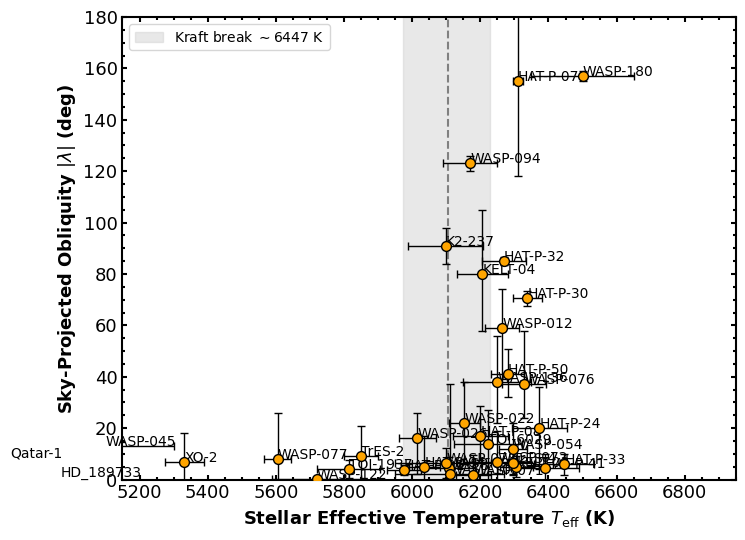

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))

ax.errorbar(teff, lam,
            xerr=[tefflerr, teffuerr], yerr=[lamlerr, lamuerr],
            fmt='o', color='k', elinewidth=1, capsize=3)
ax.scatter(teff, lam, color='orange', s=50, edgecolor='k', zorder=10)
for i in range(len(System)):
    ax.text(teff[i], lam[i], System[i])
# Reference Kraft-break range (from Wang+2026; will be re-derived below)
if 'single' in file_name:
    cut = 6447
    ax.axvspan(cut-119, cut+85, color='lightgrey', alpha=0.5, zorder=0,
            label=r'Kraft break $\sim$6447 K')
    ax.axvline(cut, color='grey', ls='--', zorder=0)
else:
    cut = 6105
    ax.axvspan(cut-133, cut+123, color='lightgrey', alpha=0.5, zorder=0,
            label=r'Kraft break $\sim$6447 K')
    ax.axvline(cut, color='grey', ls='--', zorder=0)

ax.set_xlim(5150, 6950)
ax.set_ylim(0, 180)
ax.set_xlabel(r'Stellar Effective Temperature $T_{\rm eff}$ (K)', fontsize=13, weight='bold')
ax.set_ylabel(r'Sky-Projected Obliquity $|\lambda|$ (deg)', fontsize=13, weight='bold')
ax.legend(loc='upper left', fontsize=10)
ticksetax(ax)
plt.tight_layout()
plt.show()

## 3. Illustration: a single sliding KS-test scan

Before running the full Monte Carlo loop, here is what a **single realisation**
looks like: for every candidate temperature cut, we split the sample into a
cool and a hot subset and run a two-sample KS test on the $|\lambda|$ values.
The cut that maximises the KS significance $-\log_{10} p$ is the best-fit
Kraft-break temperature for that realisation.

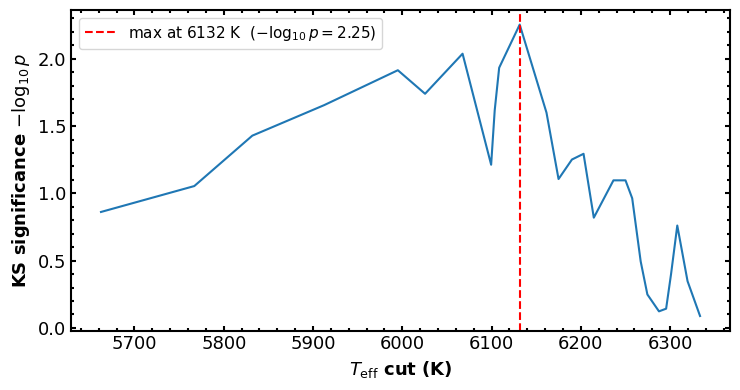

In [ ]:
def ks_scan(teff_arr, lam_arr, min_per_side=5):
    """Slide a Teff cut across the sample and return (cuts, -log10 p)."""
    order = np.argsort(teff_arr)
    t_sorted = teff_arr[order]
    candidates = 0.5 * (t_sorted[1:] + t_sorted[:-1])
    cuts, sigs = [], []
    for c in candidates:
        left  = lam_arr[teff_arr <  c]
        right = lam_arr[teff_arr >= c]
        if len(left) < min_per_side or len(right) < min_per_side:
            continue
        _, p = scipy.stats.ks_2samp(left, right)
        cuts.append(c)
        sigs.append(-np.log10(p + 1e-300))
    return np.array(cuts), np.array(sigs)

cuts0, sigs0 = ks_scan(teff, lam)
best_cut0    = cuts0[np.argmax(sigs0)]
best_sig0    = np.max(sigs0)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(cuts0, sigs0, color='C0', lw=1.5)
ax.axvline(best_cut0, color='red', ls='--', label=f'max at {best_cut0:.0f} K  '
                                                   f'($-\\log_{{10}}p={best_sig0:.2f}$)')
ax.set_xlabel(r'$T_{\rm eff}$ cut (K)', fontsize=13, weight='bold')
ax.set_ylabel(r'KS significance $-\log_{10}p$', fontsize=13, weight='bold')
ax.legend(fontsize=11)
ticksetax(ax)
plt.tight_layout()
plt.show()

## 4. Bootstrap + Monte Carlo loop

For each of $N$ iterations:

1. Draw a bootstrap sample of size $N_{\rm sys}$ with replacement.
2. Perturb each point's $T_{\rm eff}$ and $|\lambda|$ by a Gaussian whose width
   is the mean of its upper and lower 1$\sigma$ uncertainties.
3. Run the sliding KS scan on the perturbed sample and store the temperature
   at which the KS significance peaks.

The spread in the $N$ best-cut values quantifies the uncertainty on the
Kraft-break temperature.

In [ ]:
n_iter = 1000  # Number of bootstrap + MC iterations. Use a large number, e.g., 100,000, to obtain publication-quality statistics.
n_sys     = len(teff)
best_cuts = np.empty(n_iter)

teff_sig = 0.5 * (tefflerr + teffuerr)  # A better approach would be to use a skewed Gaussian distribution.
lam_sig  = 0.5 * (lamlerr  + lamuerr)   # A better approach would be to use a skewed Gaussian distribution.

for i in range(n_iter):
    if i % 1000 == 0:
        print(f'  iteration {i:5d} / {n_iter}')
    idx = rng.integers(0, n_sys, n_sys)                  # bootstrap indices
    t_i = rng.normal(teff[idx], teff_sig[idx])           # perturbed Teff
    l_i = rng.normal(lam[idx],  lam_sig[idx])            # perturbed |lambda|
    cuts_i, sigs_i = ks_scan(t_i, l_i)
    best_cuts[i] = cuts_i[np.argmax(sigs_i)] if len(cuts_i) else np.nan

# Drop NaNs and unphysical Teff > 10000 K outliers
best_cuts = best_cuts[np.isfinite(best_cuts) & (best_cuts < 10000)]
print(f'\nkept {len(best_cuts)} / {n_iter} valid realisations')

  iteration     0 / 1000

kept 1000 / 1000 valid realisations


## 5. Distribution of the maximum-significance cut

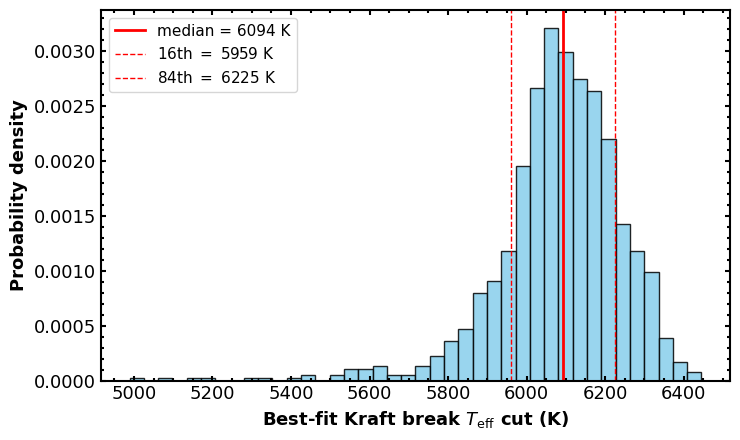


=== Empirical Kraft break ===
  T_KB = 6094 -135/+131 K
  (mean = 6082 K, std = 165 K)


In [ ]:
q16, q50, q84 = np.percentile(best_cuts, [16, 50, 84])
lerr, uerr    = q50 - q16, q84 - q50

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.hist(best_cuts, bins=40, color='skyblue', edgecolor='black', alpha=0.85, density=True)
ax.axvline(q50,        color='red',   lw=2, label=f'median = {q50:.0f} K')
ax.axvline(q16,        color='red',   lw=1, ls='--', label=f'16th $=$ {q16:.0f} K')
ax.axvline(q84,        color='red',   lw=1, ls='--', label=f'84th $=$ {q84:.0f} K')
ax.set_xlabel(r'Best-fit Kraft break $T_{\rm eff}$ cut (K)', fontsize=13, weight='bold')
ax.set_ylabel('Probability density', fontsize=13, weight='bold')
ax.legend(fontsize=11)
ticksetax(ax)
plt.tight_layout()
plt.show()

print(f'\n=== Empirical Kraft break ===')
print(f'  T_KB = {q50:.0f} -{lerr:.0f}/+{uerr:.0f} K')
print(f'  (mean = {np.mean(best_cuts):.0f} K, std = {np.std(best_cuts):.0f} K)')

## 6. Comparison with the sample

Overlay the recovered Kraft-break temperature on the $|\lambda|$ versus $T_{\rm eff}$ plot.

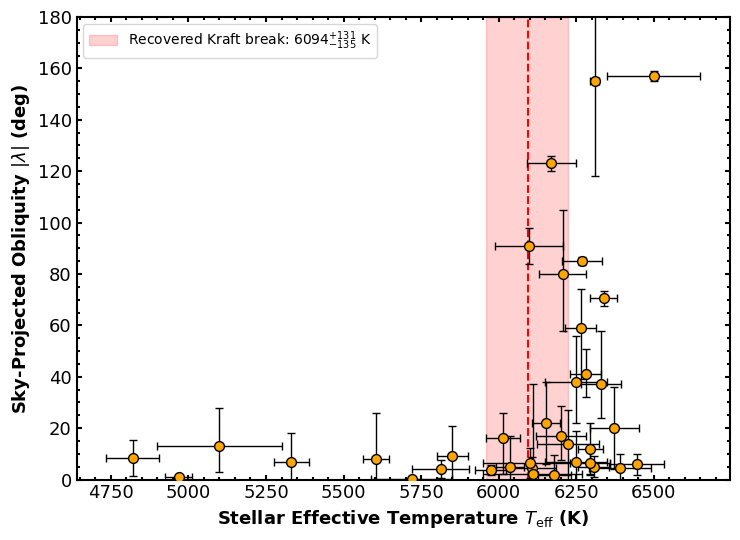

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))

ax.errorbar(teff, lam, xerr=[tefflerr, teffuerr], yerr=[lamlerr, lamuerr],
            fmt='o', color='k', elinewidth=1, capsize=3)
ax.scatter(teff, lam, color='orange', s=50, edgecolor='k', zorder=10)

ax.axvspan(q16, q84, color='red', alpha=0.18, zorder=0,
           label=f'Recovered Kraft break: ${q50:.0f}_{{-{lerr:.0f}}}^{{+{uerr:.0f}}}$ K')
ax.axvline(q50, color='red', ls='--', zorder=0)

# ax.set_xlim(5150, 6950)
ax.set_ylim(0, 180)
ax.set_xlabel(r'Stellar Effective Temperature $T_{\rm eff}$ (K)', fontsize=13, weight='bold')
ax.set_ylabel(r'Sky-Projected Obliquity $|\lambda|$ (deg)', fontsize=13, weight='bold')
ax.legend(loc='upper left', fontsize=10)
ticksetax(ax)
plt.tight_layout()
plt.show()